<a href="https://colab.research.google.com/github/Hiramalyk/DAY-12AI-ML/blob/main/Day%2013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

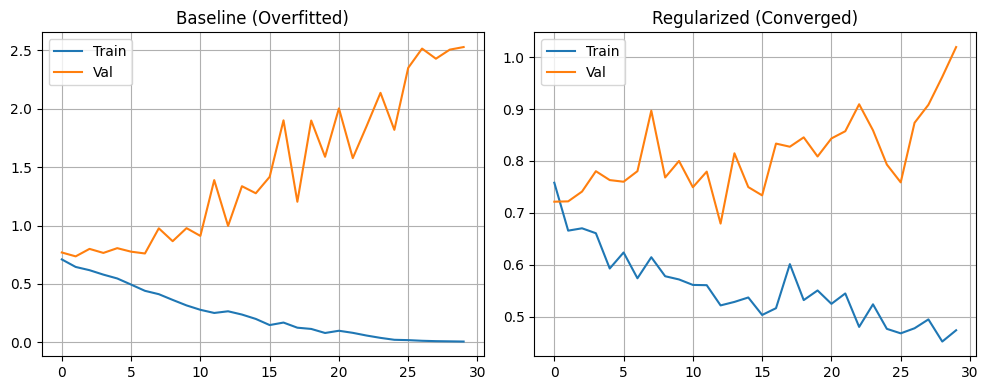

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# 1. Random Seed
torch.manual_seed(42)

# 2. Short Synthetic Data & Loaders
X_train, y_train = torch.randn(200, 10), (torch.randn(200, 10).sum(dim=1) > 0).long()
X_val, y_val = torch.randn(50, 10), (torch.randn(50, 10).sum(dim=1) > 0).long()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

# 3. Architectures
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)

class RegularizedMLP(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=2, dropout_p=0.3):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.drop1 = nn.Dropout(p=dropout_p)
        self.relu1 = nn.ReLU()

        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.drop2 = nn.Dropout(p=dropout_p)
        self.relu2 = nn.ReLU()

        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.relu1(self.drop1(self.bn1(self.layer1(x))))
        x = self.relu2(self.drop2(self.bn2(self.layer2(x))))
        return self.out(x)

# 4. Compact Training Loop
def train_model(model, t_loader, v_loader):
    opt = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    t_losses, v_losses = [], []

    for epoch in range(30):
        model.train() # State Toggle
        t_loss = 0.0
        for bx, by in t_loader:
            opt.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            opt.step()
            t_loss += loss.item() * bx.size(0)
        t_losses.append(t_loss / len(t_loader.dataset))

        model.eval() # State Toggle
        v_loss = 0.0
        with torch.no_grad():
            for bx, by in v_loader:
                v_loss += criterion(model(bx), by).item() * bx.size(0)
        v_losses.append(v_loss / len(v_loader.dataset))

    return t_losses, v_losses

# Train both
b_train, b_val = train_model(BaselineMLP(), train_loader, val_loader)
r_train, r_val = train_model(RegularizedMLP(), train_loader, val_loader)

# 5. Plotting Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(b_train, label='Train'), plt.plot(b_val, label='Val')
plt.title('Baseline (Overfitted)'), plt.legend(), plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(r_train, label='Train'), plt.plot(r_val, label='Val')
plt.title('Regularized (Converged)'), plt.legend(), plt.grid(True)

plt.tight_layout()
plt.show()